In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_predict, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor

Sia's Mount

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
folder = "/content/drive/MyDrive/ML/"

Mounted at /content/drive


Melinda's Mount

In [2]:
from google.colab import drive
drive.mount("/content/drive")
folder = "/content/drive/MyDrive/Form VI/Machine Learning/"

Mounted at /content/drive


In [3]:
# Create a dataframe
dataframe = pd.read_csv(folder + "spotify-2023.csv", encoding = "latin1")
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [4]:
# Convert streams from object to float
dataframe["streams"] = pd.to_numeric(dataframe["streams"], errors="coerce")
column_names = ['released_year', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts',
                'in_deezer_charts', 'danceability_%', 'streams']
df = dataframe[column_names]
# Handle missing values
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   released_year         952 non-null    int64  
 1   in_spotify_playlists  952 non-null    int64  
 2   in_spotify_charts     952 non-null    int64  
 3   in_apple_playlists    952 non-null    int64  
 4   in_apple_charts       952 non-null    int64  
 5   in_deezer_charts      952 non-null    int64  
 6   danceability_%        952 non-null    int64  
 7   streams               952 non-null    float64
dtypes: float64(1), int64(7)
memory usage: 66.9 KB


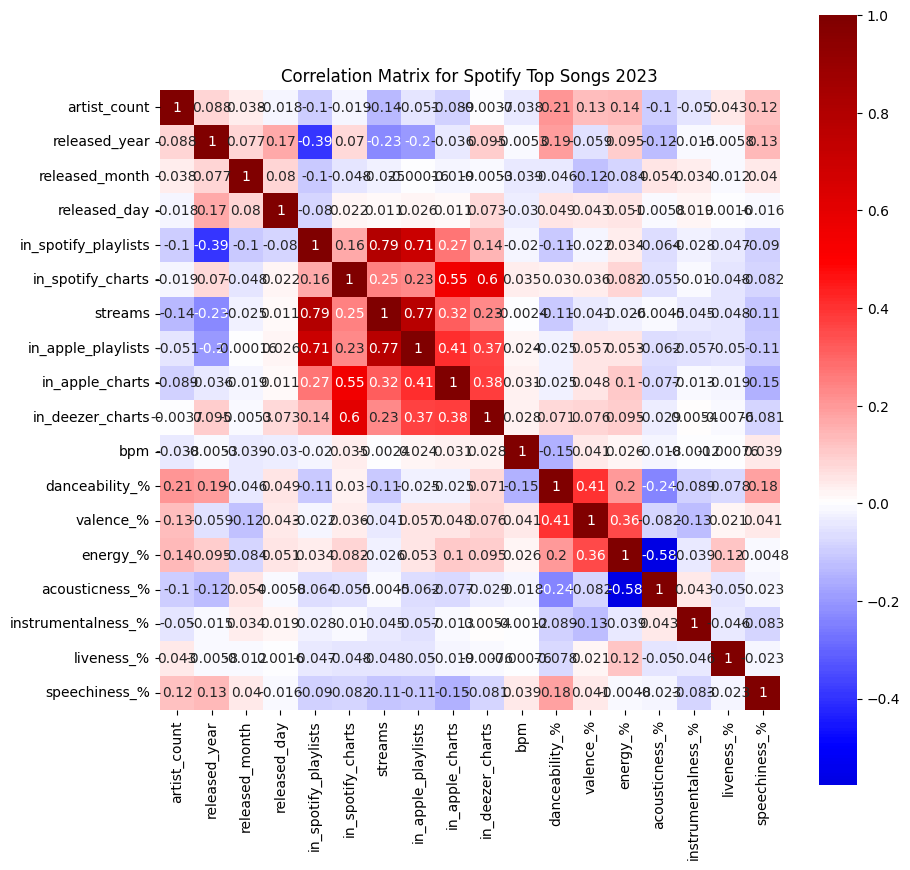

In [5]:
# Take only numerical values and create a dataframe
numerical_data = ['artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams',
                  'in_apple_playlists', 'in_apple_charts', 'in_deezer_charts', 'bpm', 'danceability_%',
                  'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
numerical_df = dataframe[numerical_data]
# Create a correlation matrix
correlation = numerical_df.corr()
plt.figure(figsize = (10,10))
sns.heatmap(correlation, square = True, annot = True, center = 0, cmap = "seismic")
plt.title("Correlation Matrix for Spotify Top Songs 2023")
plt.savefig("CorrelationMatrixSpotify.jpg", bbox_inches='tight')
plt.show()

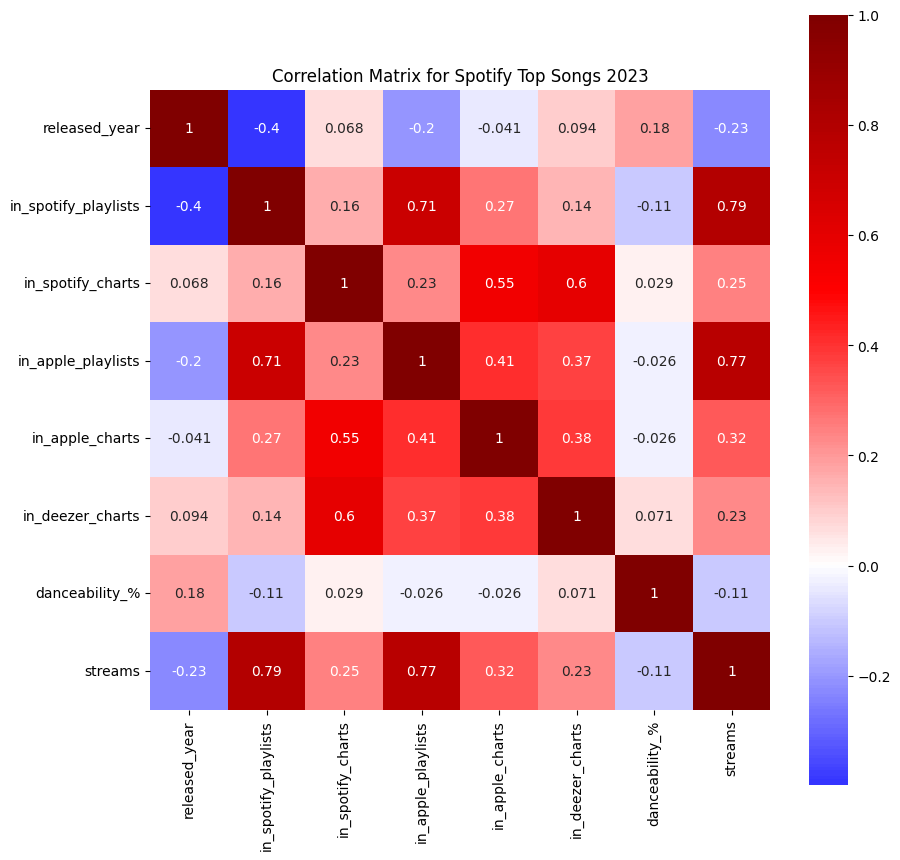

In [6]:
# Create correlation matrix with only selected features
correlation = df.corr()
plt.figure(figsize = (10,10))
sns.heatmap(correlation, square = True, annot = True, center = 0, cmap = "seismic")
plt.title("Correlation Matrix for Spotify Top Songs 2023")
plt.savefig("CorrelationMatrixSpotify.jpg", bbox_inches='tight')
plt.show()

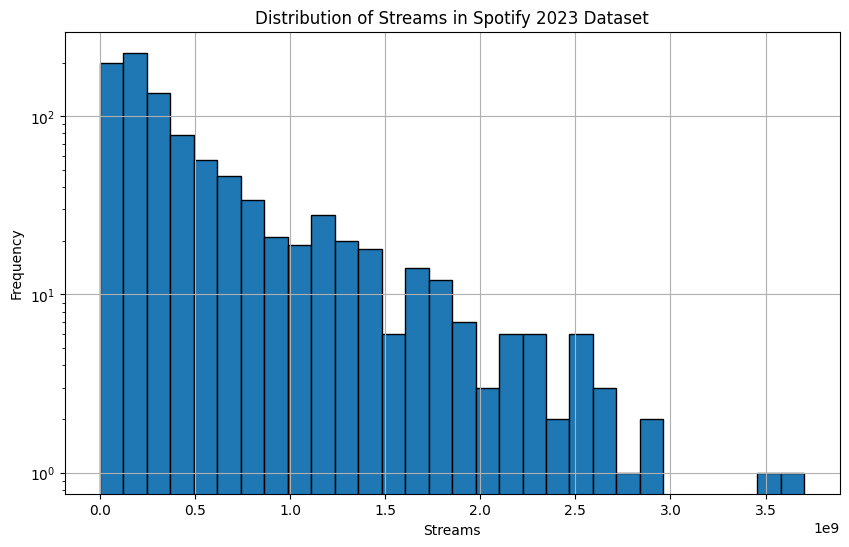

In [7]:
# Plot histogram for 'streams'
plt.figure(figsize=(10, 6))
plt.hist(df["streams"], bins=30, edgecolor="black")
plt.xlabel("Streams")
plt.ylabel("Frequency")
plt.title("Distribution of Streams in Spotify 2023 Dataset")
plt.yscale("log")
plt.grid(True)

# Display the plot
plt.show()

- Linear Regression
- Decision Trees
- k-Nearest Neighbors
- Support Vector Machines (SVR Class from svm model)

In [8]:
# Linear Regression - k-fold cross validation
numeric_features = column_names[:-1]
X = df[numeric_features]
y = df["streams"]

model = LinearRegression()

# Create K-Fold cross-validation with shuffling
kf = KFold(n_splits=5, shuffle=True)

# Perform cross-validation
neg_mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

# Convert negative MSE to RMSE
rmse_scores = np.sqrt(-neg_mse_scores)

# Compute mean and standard deviation of RMSE
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

# Print results
print("Best RMSE: ", rmse_mean)
print("RMSE Standard Deviation: ", rmse_std)

Best RMSE:  295451088.2266533
RMSE Standard Deviation:  40797341.51742546


In [9]:
# Decision Trees
X = df[numeric_features]
y = df["streams"]

# Initialize the Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1)

# Perform the hyperparameter search
grid_search.fit(X, y)

# Retrieve the best model and its parameters
best_params = grid_search.best_params_

# Get the index of the best hyperparameters
best_index = grid_search.best_index_

# Extract negative MSE scores for all folds of the best model
mse_scores = [
    grid_search.cv_results_[f'split{i}_test_score'][best_index]
    for i in range(5)
]

# Convert negative MSE to RMSE
rmse_scores = np.sqrt([-score for score in mse_scores])

# Calculate mean and standard deviation
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

print("Best RMSE (mean):", rmse_mean)
print("RMSE Standard Deviation:", rmse_std)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RMSE (mean): 281409259.08945215
RMSE Standard Deviation: 83860560.42267248


In [10]:
# K Nearest Neighbors

# Define X (features) and y (target)
X = df[numeric_features]
y = df['streams']

# Create a pipeline with StandardScaler and KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__weights': ['uniform', 'distance']
}

# Initialize K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metric (Negative RMSE for minimizing)
scoring = {
    'MSE': 'neg_mean_squared_error'
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, refit='MSE', cv=kf, verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_

# Get the index of the best hyperparameters
best_index = grid_search.best_index_

# Extract negative MSE scores from each fold for the best estimator
mse_scores = [
    grid_search.cv_results_[f'split{i}_test_MSE'][best_index]
    for i in range(5)
]

# Convert negative MSE to RMSE
rmse_scores = np.sqrt([-score for score in mse_scores])

# Calculate mean and standard deviation
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

# print RMSE
print(f'Best Hyperparameters: {best_params}')
print(f"Best RMSE (mean):", rmse_mean)
print(f"RMSE Standard Deviation:", rmse_std)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best RMSE (mean): 281152500.85143423
RMSE Standard Deviation: 30811826.547103472


In [11]:
# SVM
# Define X (features) and y (target)
X = df[numeric_features]
y = df['streams']

# Create a pipeline with StandardScaler and SVR
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'svr__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svr__C': [0.1, 1, 10],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

# Initialize K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metric (Negative RMSE for minimizing)
scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, refit='MSE', cv=kf, verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X, y)

# Retrieve the best model and its parameters
best_params = grid_search.best_params_

# Get the index of the best hyperparameters
best_index = grid_search.best_index_

# Extract the negative MSE scores from each fold for the best estimator
mse_scores = [
    grid_search.cv_results_[f'split{i}_test_MSE'][best_index]
    for i in range(5)
]

# Convert negative MSE to RMSE
rmse_scores = np.sqrt([-score for score in mse_scores])

# Calculate mean and standard deviation
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

# Display the best hyperparameters and the corresponding RMSE
print(f'Best Hyperparameters: {best_params}')
print(f"Best RMSE (mean):", rmse_mean)
print(f"RMSE Standard Deviation:", rmse_std)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__kernel': 'linear'}
Best RMSE (mean): 606518935.6505244
RMSE Standard Deviation: 53972242.063406825


In [12]:
# Ensemble Learning
# Define cross-validation strategy
kfold = KFold(n_splits=5, random_state=7, shuffle=True)

# Create all the models
model1 = LinearRegression()
model2 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=1, min_samples_split=2)
model3 = KNeighborsRegressor(metric='manhattan', n_neighbors=5, weights='distance')

# Create a list of models
estimators = [
    ("linear", model1),
    ("cart", model2),
    ("knn", model3)
]

# Create ensemble using VotingRegressor
ensemble = VotingRegressor(estimators)

# Evaluate the ensemble model using RMSE
mse_scores = cross_val_score(ensemble, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Convert negative MSE to positive RMSE
rmse_scores = np.sqrt(-mse_scores)

# Calculate mean and standard deviation
rmse_mean = rmse_scores.mean()
rmse_std = rmse_scores.std()

# Print mean RMSE
print("Best RMSE:", rmse_mean)
print("RMSE Standard Deviation:", rmse_std)

Best RMSE: 271430494.95973694
RMSE Standard Deviation: 19414498.289653853
